In [1]:
import pyvisa
import numpy as np
import time
from abc import ABC, abstractmethod
from typing import Sequence, Optional, Tuple, Any
import matplotlib.pyplot as plt
from function_generator_functions import * 
#Reload the function generator functions to get the latest changes
import importlib

from __future__ import annotations
import scipy.interpolate as interpolate
import h5py as h5
from Oscilloscope import digitizer_base
importlib.reload(digitizer_base)
from Oscilloscope.digitizer_base import Digitizer
scope_module = importlib.import_module("Oscilloscope.Scope")
importlib.reload(scope_module)
from Oscilloscope.Scope import Scope
import matplotlib.pyplot as plt
import os

In [2]:
pattern = "SDG2XFBX801056"
pc_ip = "169.254.102.162"
func_gen = "169.254.102.160"

In [19]:
# if __name__ == "__main__":
#     # Your specific VISA address for Ethernet
#     my_visa_address = "TCPIP0::169.254.102.160::inst0::INSTR"
    
#     print(f"Attempting to connect to: {my_visa_address}")
    
#     try:
#         # Initialize the RSDG class with your Ethernet address
#         fg = RSDG(visa_address=my_visa_address)
        
#         print("Success! Generator is configured.")

#     except Exception as e:
#         print(f"Error connecting to the generator: {e}")

In [103]:
# offsets = np.linspace(0, -1.6, 100)
# fg.set_square_wave(chn=1, freq=10, amp=1e-2, offset=-1.9)

# fg.set_output(chn=1, enable=True, load='50')


In [106]:
# #Turn off output after testing
# fg.set_output(chn=1, enable=False)

In [3]:
#Connect to scope
scope_ip = "169.254.251.130"
if __name__ == "__main__":
    # # 1. Update this with the IP address found on the scope's screen
    # scope_address = f"TCPIP0::{scope_ip}::hislip0::INSTR"

    # # 2. Update this with the IP you set for your Function Generator earlier
    # fg_address = f"TCPIP0::{func_gen}::inst0::INSTR"
    # Function Generator Address
    fg_address = "TCPIP0::192.168.1.10::inst0::INSTR"

    # Scope Address (Revert to inst0)
    scope_address = "TCPIP0::192.168.2.10::inst0::INSTR"

    try:
        # Connect to the Oscilloscope
        print("Connecting to Scope...")
        scope = Scope(visa_address=scope_address)
        
        # Connect to the Function Generator (using your RSDG class from before)
        print("Connecting to Function Generator...")
        fg = RSDG(visa_address=fg_address)


    except Exception as e:
        print(f"Connection failed: {e}")

Connecting to Scope...
Connecting to Function Generator...
Func Gen: connected to: RS, ,SDG2XFBX801056,2.01.01.38



In [36]:
import time

# 1. Clear the hardware-level buffers
scope.DSO.clear() 
time.sleep(1)

# 2. Nuclear Reset: Clear all errors until the queue is empty
print("Clearing error queue...")
for _ in range(10):
    try:
        err = scope.DSO.query(":SYSTem:ERRor?")
        print(f"Cleared: {err}")
        if "No error" in err: break
    except:
        scope.DSO.clear()

# 3. Force the scope back to a "safe" state
scope.DSO.write("*CLS")
scope.DSO.write(":SYSTem:LOCal")
print("Scope is now clean and ready.")

Clearing error queue...
Cleared: +0,"No error"
Scope is now clean and ready.


Starting acquisition...
[0.00000000e+00 1.00806452e-05 2.01612903e-05 3.02419355e-05
 4.03225806e-05 5.04032258e-05 6.04838710e-05 7.05645161e-05
 8.06451613e-05 9.07258065e-05 1.00806452e-04 1.10887097e-04
 1.20967742e-04 1.31048387e-04 1.41129032e-04 1.51209677e-04
 1.61290323e-04 1.71370968e-04 1.81451613e-04 1.91532258e-04
 2.01612903e-04 2.11693548e-04 2.21774194e-04 2.31854839e-04
 2.41935484e-04 2.52016129e-04 2.62096774e-04 2.72177419e-04
 2.82258065e-04 2.92338710e-04 3.02419355e-04 3.12500000e-04
 3.22580645e-04 3.32661290e-04 3.42741935e-04 3.52822581e-04
 3.62903226e-04 3.72983871e-04 3.83064516e-04 3.93145161e-04
 4.03225806e-04 4.13306452e-04 4.23387097e-04 4.33467742e-04
 4.43548387e-04 4.53629032e-04 4.63709677e-04 4.73790323e-04
 4.83870968e-04 4.93951613e-04 5.04032258e-04 5.14112903e-04
 5.24193548e-04 5.34274194e-04 5.44354839e-04 5.54435484e-04
 5.64516129e-04 5.74596774e-04 5.84677419e-04 5.94758065e-04
 6.04838710e-04 6.14919355e-04 6.25000000e-04 6.35080645e-04


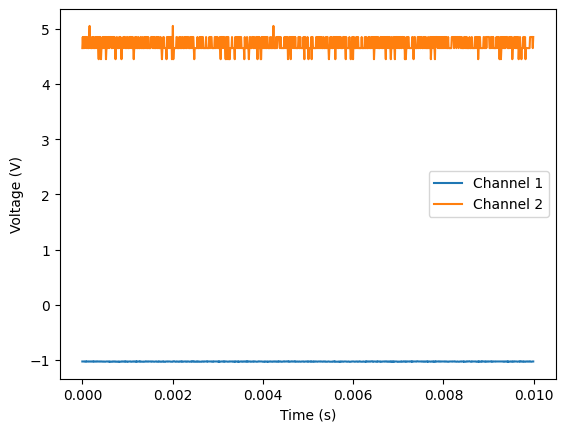

Success!


In [25]:
# import matplotlib.pyplot as plt

# # 1. Clear Errors and UNLOCK the front panel buttons
# scope.DSO.write("*CLS")
# scope.DSO.write(":SYSTem:LOCal") 

# # 2. Set the Trigger to AUTO so it captures immediately
# scope.DSO.write(":TRIGger:SWEep AUTO")

# # 3. SET DATA POINTS CORRECTLY
# # Use :WAVeform:POINts instead of :ACQuire:POINts
# # We use 'int' to ensure we don't send a decimal (like 100.0)
# scope.DSO.write(":WAVeform:POINts:MODE NORMal") 
# scope.DSO.write(f":WAVeform:POINts {int(1000)}") 

# # 4. Set high timeout for Ethernet transfer
# scope.DSO.timeout = 100000/3  # 100 seconds divided by 3 to be safe
# channels = [1, 2]
# t, y = scope.acquire2(channels=channels)

In [4]:
# photo_detector_data = y[0]  # Assuming channel 1 is the photodetector
# controller_data = y[1]  # Assuming channel 2 is the temperature sensor



def voltage_to_kOhm(voltage):
    r = voltage * 20
    return np.asarray(r)
# resist = voltage_to_kOhm(controller_data)
temperature = np.array([
    -40, -35, -30, -25, -20, -15, -10, -5,
      0,   5,  10,  15,  20,  25,  30,  35,
     40,  45,  50,  55,  60,  65,  70,  75,
     80,  85,  90,  95, 100
])
resistance_nominal = np.array([
    2664.0, 1933.0, 1421.0, 1052.0,  788.5,  594.4,  453.0,  347.6,
     269.3,  209.7,  164.8,  130.1,  103.6,   83.00,  66.91,  54.19,
      44.18,  36.17,  29.80,  24.65,  20.51,  17.13,  14.37,  12.10,
      10.24,   8.700,  7.419,  6.351,  5.460
]) #kOhm
fit = interpolate.interp1d(temperature, resistance_nominal, kind='cubic')
temperature_fit = np.linspace(temperature.min(), temperature.max(), 100)
resistance_fit = fit(temperature_fit)
def temperature_from_resistance(res):
    """
    Calculate the temperature corresponding to a given resistance using the cubic spline fit.
    """
    # Create an inverse function for the fit
    inverse_fit = interpolate.interp1d(resistance_fit, temperature_fit, kind='cubic', fill_value="extrapolate")
    return inverse_fit(res)
# temp = temperature_from_resistance(resist)




# # Plot the acquired data
# fig, axs = plt.subplots(2, 1, figsize=(12, 8))
# axs[0].plot(t, photo_detector_data, label='Photodetector Signal')
# axs[0].set_title('Photodetector Signal vs Time')
# axs[0].set_xlabel('Time (s)')
# axs[0].set_ylabel('Voltage (V)')
# axs[0].legend()
# axs[1].plot(t, resist, label='Controller Data', color='blue')
# axs[1].set_title('Controller Data vs Time')
# axs[1].set_xlabel('Time (s)')
# axs[1].set_ylabel('Resistance (Ohms)')
# axs[1].legend()
# plt.tight_layout()


In [15]:
# scope.DSO.write(":SYSTem:LOCal")

14

In [5]:
def clear_scope():
    # 1. Clear the hardware-level buffers
    scope.DSO.clear() 
    time.sleep(1)

    # 2. Nuclear Reset: Clear all errors until the queue is empty
    print("Clearing error queue...")
    for _ in range(10):
        try:
            err = scope.DSO.query(":SYSTem:ERRor?")
            print(f"Cleared: {err}")
            if "No error" in err: break
        except:
            scope.DSO.clear()

    # 3. Force the scope back to a "safe" state
    scope.DSO.write("*CLS")
    scope.DSO.write(":SYSTem:LOCal")
    print("Scope is now clean and ready.")

from datetime import datetime
from datetime import timedelta

def measure_scope(channels=[1, 2]):
    try:
        # Standardize settings for every measurement to ensure stability
        scope.DSO.write("*CLS")
        scope.DSO.write(":TRIGger:SWEep AUTO")
        scope.DSO.write(":WAVeform:POINts:MODE NORMal") 
        scope.DSO.write(f":WAVeform:POINts {int(1000)}") 
        
        # Using the acquire2 we fixed earlier
        t, y = scope.acquire2(channels=channels)
        
        # Calculate means for each channel
        # y has shape (num_channels, num_points)
        avgs = [np.mean(ch_data) for ch_data in y]
        #standard deviation
        std = [np.std(ch_data) for ch_data in y]
        return t, y, avgs, std
    except Exception as e:
        print(f"Scope error during measurement: {e}")
        return None, None, None, None

def overnight_measure(total_time=3600, n_measurements=10, channels=[1, 2]):
    clear_scope()
    
    generator_offsets = np.linspace(0, -1.9, n_measurements) #to 13 resist
    measurement_interval = total_time / n_measurements
    
    # Create filename with timestamp now so we can save incrementally
    start_time_str = datetime.now().strftime('%d-%m-%Y_%H-%M')
    filename = f"Overnight_data\\Overnight_data_{start_time_str}.csv"
    
    print(f"Starting experiment. Data will be saved to {filename}")
    print(f"Total Time: {total_time}s, Measurements: {n_measurements}, Interval: {measurement_interval:.1f}s")
    print(f"Will be finished at approximately: {(datetime.now() + timedelta(seconds=total_time)).strftime('%H:%M:%S')}")
    
    results = []

    for i in range(n_measurements):
        current_offset = generator_offsets[i]
        print(f"[{i+1}/{n_measurements}] Setting Offset to {current_offset:.3f}V...")
        
        # 1. Set Temperature
        fg.set_square_wave(chn=1, freq=10, amp=1e-2, offset=current_offset)
        fg.set_output(chn=1, enable=True, load='50')
        
        # 2. WAIT for thermal equilibrium BEFORE measuring
        # We wait for the interval BEFORE the measurement
        if i > 0: # Don't wait before the very first one if it's already at start temp
            print(f"Waiting {measurement_interval:.1f}s for thermal settling...")
            time.sleep(measurement_interval)
        
        # 3. Measure
        t_data, y_data, avgs, std = measure_scope(channels=channels)
        
        if avgs is not None:
            # Store timestamp, offset, and the averages
            timestamp = i * measurement_interval
            row = [timestamp, current_offset] + avgs + std
            results.append(row)
            
            # 4. Incremental Save (Saves data even if it crashes later!)
            header = "Time_s,Offset_V," + ",".join([f"Ch{c}_Avg" for c in channels]) + "," + ",".join([f"Ch{c}_Std" for c in channels])
            np.savetxt(filename, np.array(results), delimiter=',', header=header, comments='')
        else:
            print("Measurement failed, attempting to clear scope for next round...")
            clear_scope()

    # Cleanup
    fg.set_output(chn=1, enable=False)
    print(f"Experiment Complete. Final data in {filename}")


In [6]:
test_time = 60*60 # 1 hours for testing
overnight_measure(total_time=test_time, n_measurements=45, channels=[1, 2])

Clearing error queue...
Cleared: +0,"No error"
Scope is now clean and ready.
Starting experiment. Data will be saved to Overnight_data\Overnight_data_30-03-2026_14-46.csv
Total Time: 3600s, Measurements: 45, Interval: 80.0s
Will be finished at approximately: 15:46:46
[1/45] Setting Offset to 0.000V...
[2/45] Setting Offset to -0.043V...
Waiting 80.0s for thermal settling...
[3/45] Setting Offset to -0.086V...
Waiting 80.0s for thermal settling...
[4/45] Setting Offset to -0.130V...
Waiting 80.0s for thermal settling...
[5/45] Setting Offset to -0.173V...
Waiting 80.0s for thermal settling...
[6/45] Setting Offset to -0.216V...
Waiting 80.0s for thermal settling...
[7/45] Setting Offset to -0.259V...
Waiting 80.0s for thermal settling...
[8/45] Setting Offset to -0.302V...
Waiting 80.0s for thermal settling...
[9/45] Setting Offset to -0.345V...
Waiting 80.0s for thermal settling...
[10/45] Setting Offset to -0.389V...
Waiting 80.0s for thermal settling...
[11/45] Setting Offset to -0.4

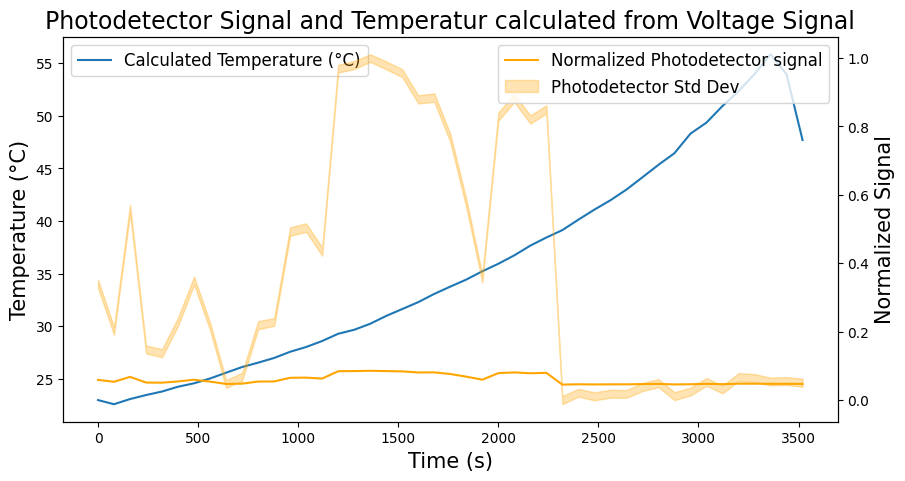

In [ ]:
filepath = r"Overnight_data\Overnight_data_30-03-2026_14-46.csv" # Update with your actual filename
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
time_data = data[:, 0]
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
std = data[:, 4:]  # Standard deviations for each channel

resist = voltage_to_kOhm(channel2)
temperature = temperature_from_resistance(resist)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))

# Use raw channel1 data for the shaded region
top_shaded = channel1 + std[:, 0]
bottom_shaded = channel1 - std[:, 0]

axs.plot(time_data, temperature, label='Calculated Temperature (°C)')
axs.set_title('Photodetector Signal and Temperatur calculated from Voltage Signal',fontsize=17)
axs.set_xlabel('Time (s)',fontsize=15)
axs.set_ylabel('Temperature (°C)',fontsize=15)
axs2 = axs.twinx()

# Plot raw channel1 data
axs2.plot(time_data, channel1, label='Photodetector signal', color='orange')
axs2.fill_between(time_data, bottom_shaded, top_shaded, color='orange', alpha=0.3, label='Photodetector Std Dev')
axs2.set_ylabel('Photodetector Voltage (V)',fontsize=15)
axs.legend(loc='upper left',fontsize=12)
axs2.legend(loc='upper right',fontsize=12)

In [17]:
std

array([[0.01229938, 0.10964426],
       [0.01168081, 0.10869748],
       [0.012672  , 0.11229631],
       [0.01171604, 0.10076932],
       [0.01193436, 0.10451869],
       [0.01217873, 0.10433311],
       [0.01203522, 0.10751864],
       [0.01145851, 0.11627273],
       [0.01150737, 0.11163498],
       [0.01172601, 0.11214119],
       [0.0120239 , 0.10891237],
       [0.01131559, 0.10100759],
       [0.01259335, 0.11736367],
       [0.01239303, 0.11211775],
       [0.01191717, 0.10945237],
       [0.01146296, 0.09532213],
       [0.01174357, 0.0959378 ],
       [0.01109279, 0.11428969],
       [0.01160805, 0.11794435],
       [0.01159118, 0.11248719],
       [0.01196798, 0.10735431],
       [0.01248477, 0.10591275],
       [0.01219203, 0.0982149 ],
       [0.0124242 , 0.10625778],
       [0.01178218, 0.10029312],
       [0.01209139, 0.09973132],
       [0.01159155, 0.1097341 ],
       [0.01204776, 0.09435934],
       [0.01213701, 0.10432052],
       [0.01199847, 0.10387029],
       [0.

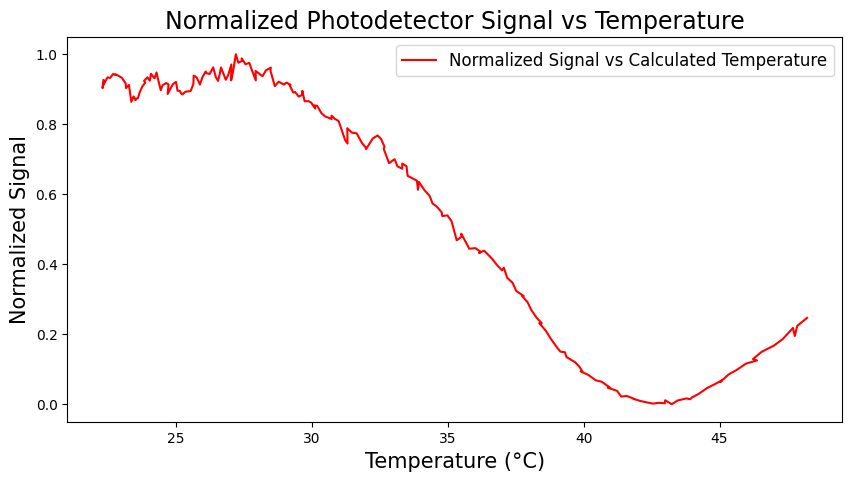

In [115]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temperature, normalized_channel1, label='Normalized Signal vs Calculated Temperature', color = 'red')
ax.set_title('Normalized Photodetector Signal vs Temperature',fontsize=17)
ax.set_xlabel('Temperature (°C)',fontsize=15)
ax.set_ylabel('Normalized Signal',fontsize=15)
ax.legend(fontsize=12)

In [118]:
test_time = 60*10 # 10 minutes for testing
n = 10
overnight_measure(total_time=test_time, n_measurements=n, channels=[1, 2])

Clearing error queue...
Cleared: +0,"No error"
Scope is now clean and ready.
Starting experiment. Data will be saved to Overnight_data\Overnight_data_30-03-2026_13-53.csv
Total Time: 600s, Measurements: 10, Interval: 60.0s
Will be finished at approximately: 14:03:52
[1/10] Setting Offset to 0.000V...
[2/10] Setting Offset to -0.178V...
Waiting 60.0s for thermal settling...
[3/10] Setting Offset to -0.356V...
Waiting 60.0s for thermal settling...
[4/10] Setting Offset to -0.533V...
Waiting 60.0s for thermal settling...
[5/10] Setting Offset to -0.711V...
Waiting 60.0s for thermal settling...
[6/10] Setting Offset to -0.889V...
Waiting 60.0s for thermal settling...
[7/10] Setting Offset to -1.067V...
Waiting 60.0s for thermal settling...
[8/10] Setting Offset to -1.244V...
Waiting 60.0s for thermal settling...
[9/10] Setting Offset to -1.422V...
Waiting 60.0s for thermal settling...
[10/10] Setting Offset to -1.600V...
Waiting 60.0s for thermal settling...
Experiment Complete. Final data

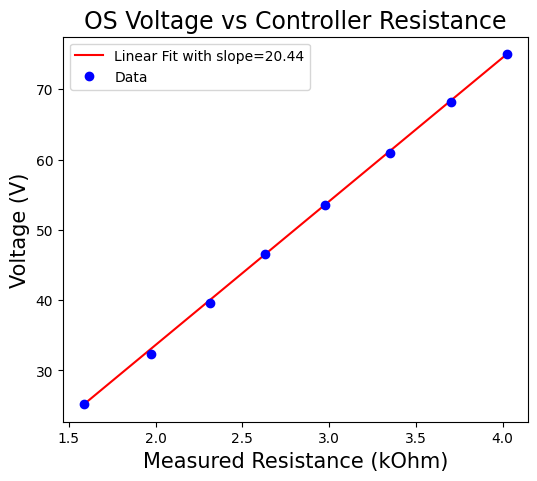

In [142]:
set_point = [75,68.14,60.9,53.6,46.6,39.6,32.3,25.2]
filepath = 'Overnight_data\Overnight_data_30-03-2026_13-53.csv'
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
time_data = data[:, 0]
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
chan = channel2[2:]
#fit of set vs resistance
fit = interpolate.interp1d(chan, set_point, kind='cubic', fill_value="extrapolate")
xfit = np.linspace(min(chan), max(chan), 100)
yfit = fit(xfit)
slope = (yfit[-1] - yfit[0]) / (xfit[-1] - xfit[0])
intercept = yfit[0] - slope * xfit[0]
yfit_linear = slope * xfit + intercept
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(xfit, yfit_linear, label='Linear Fit with slope={:.2f}'.format(slope), color='red', linestyle='-')
ax.plot(chan, set_point, label='Data', color = 'blue', marker='o', linestyle='None')
ax.set_xlabel('Measured Resistance (kOhm)',fontsize=15)
ax.set_ylabel('Voltage (V)',fontsize=15)
ax.set_title('OS Voltage vs Controller Resistance',fontsize=17)
ax.legend()
plt.show()


In [143]:
print(chan)

[4.02361938 3.70387553 3.35333254 2.97401665 2.62793143 2.31102435
 1.97365205 1.58724425]
